## Goal: Segment customers into groups based on their behavior and identify which groups are more likely to contain customers at risk of churn.

## Problem Statements:


*   Which types of customers exist?
*   Which customer segment is most valuable?
*   Which segment shows high support calls/payment delays?
*   Which segment contains more churned customers?
*   What actions should the company take for each segment?







In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load The Dataset

In [2]:
df = pd.read_csv('/content/ecommerce_customer_data_custom_ratios.csv')

In [3]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12.0,3.0,740.0,Credit Card,37.0,0.0,Christine Hernandez,37.0,Male,0.0
1,46251,2022-03-05 12:56:35,Home,468.0,4.0,2739.0,PayPal,37.0,0.0,Christine Hernandez,37.0,Male,0.0
2,46251,2022-05-23 18:18:01,Home,288.0,2.0,3196.0,PayPal,37.0,0.0,Christine Hernandez,37.0,Male,0.0
3,46251,2020-11-12 13:13:29,Clothing,196.0,1.0,3509.0,PayPal,37.0,0.0,Christine Hernandez,37.0,Male,0.0
4,13593,2020-11-27 17:55:11,Home,449.0,1.0,3452.0,Credit Card,49.0,0.0,James Grant,49.0,Female,1.0


In [4]:
df.shape

(48962, 13)

In [5]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48962 entries, 0 to 48961
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer ID            48962 non-null  int64  
 1   Purchase Date          48962 non-null  object 
 2   Product Category       48961 non-null  object 
 3   Product Price          48961 non-null  float64
 4   Quantity               48961 non-null  float64
 5   Total Purchase Amount  48961 non-null  float64
 6   Payment Method         48961 non-null  object 
 7   Customer Age           48961 non-null  float64
 8   Returns                39625 non-null  float64
 9   Customer Name          48961 non-null  object 
 10  Age                    48961 non-null  float64
 11  Gender                 48961 non-null  object 
 12  Churn                  48961 non-null  float64
dtypes: float64(7), int64(1), object(5)
memory usage: 4.9+ MB


In [7]:
df = df.drop(['Customer ID','Customer Age'],axis = 1)

## Understand The Data

In [8]:
df.describe()

,Product Price,Quantity,Total Purchase Amount,Returns,Age,Churn
count,48961.000000,48961.00000,48961.000000,39625.000000,48961.000000,48961.000000
mean,254.288556,2.99614,2720.902269,0.500669,43.639938,0.200527
std,142.057365,1.40963,1446.426391,0.500006,15.367683,0.400399
min,10.000000,1.00000,107.000000,0.000000,18.000000,0.000000
25%,130.000000,2.00000,1465.000000,0.000000,30.000000,0.000000
50%,255.000000,3.00000,2723.000000,1.000000,43.000000,0.000000
75%,378.000000,4.00000,3977.000000,1.000000,57.000000,0.000000
max,500.000000,5.00000,5350.000000,1.000000,70.000000,1.000000


In [9]:
df.isnull().sum()

,0
Purchase Date,0
Product Category,1
Product Price,1
Quantity,1
Total Purchase Amount,1
Payment Method,1
Returns,9337
Customer Name,1
Age,1
Gender,1


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

,0
Purchase Date,48953
Product Category,4
Product Price,491
Quantity,5
Total Purchase Amount,5209
Payment Method,4
Returns,2
Customer Name,7829
Age,53
Gender,2


In [12]:
df.select_dtypes(include='object').columns

Index(['Purchase Date', 'Product Category', 'Payment Method', 'Customer Name',
       'Gender'],
      dtype='object')

## EDA

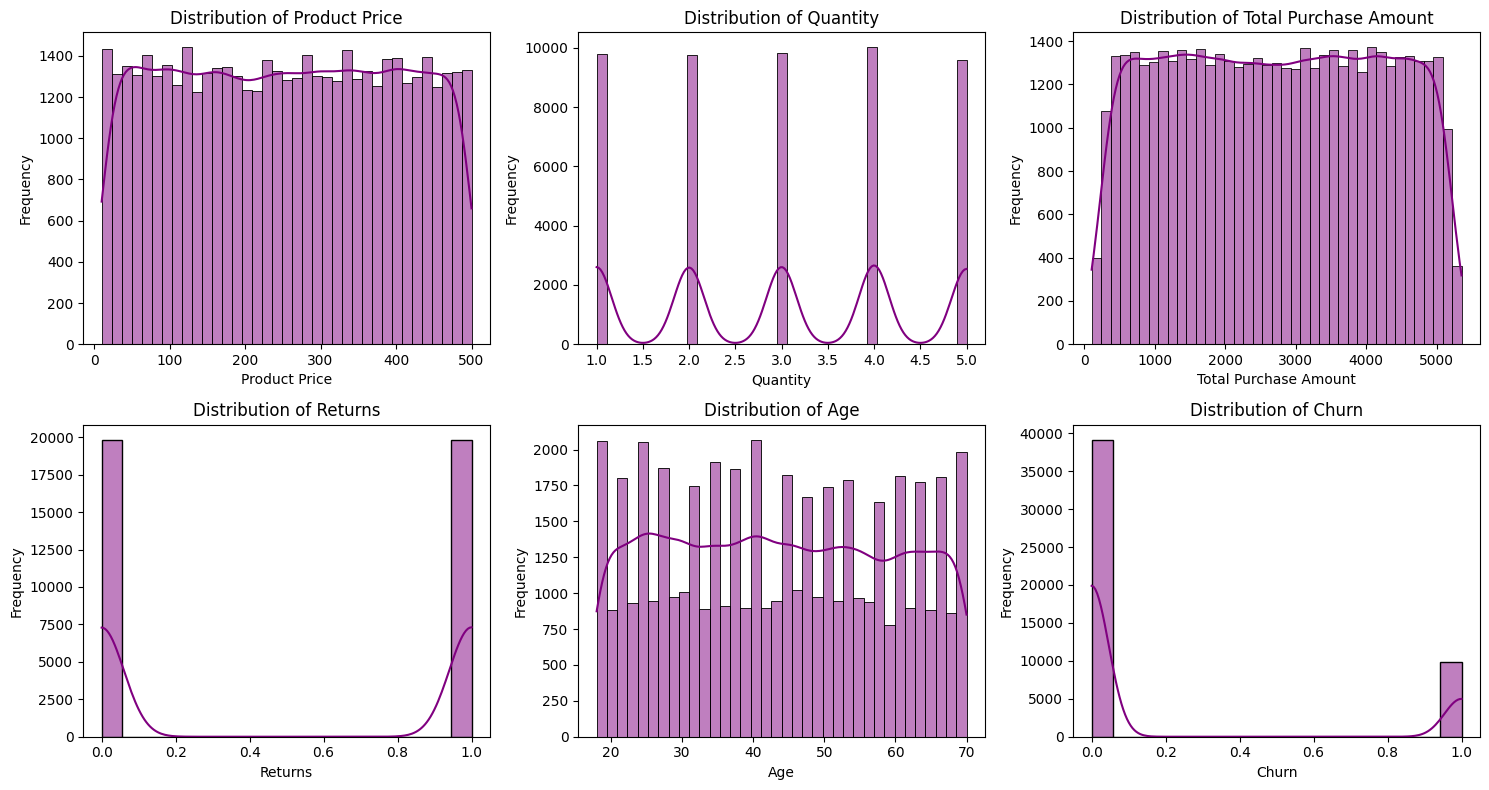

In [13]:
numeric_cols = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i],color = 'purple')

    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove empty subplots
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

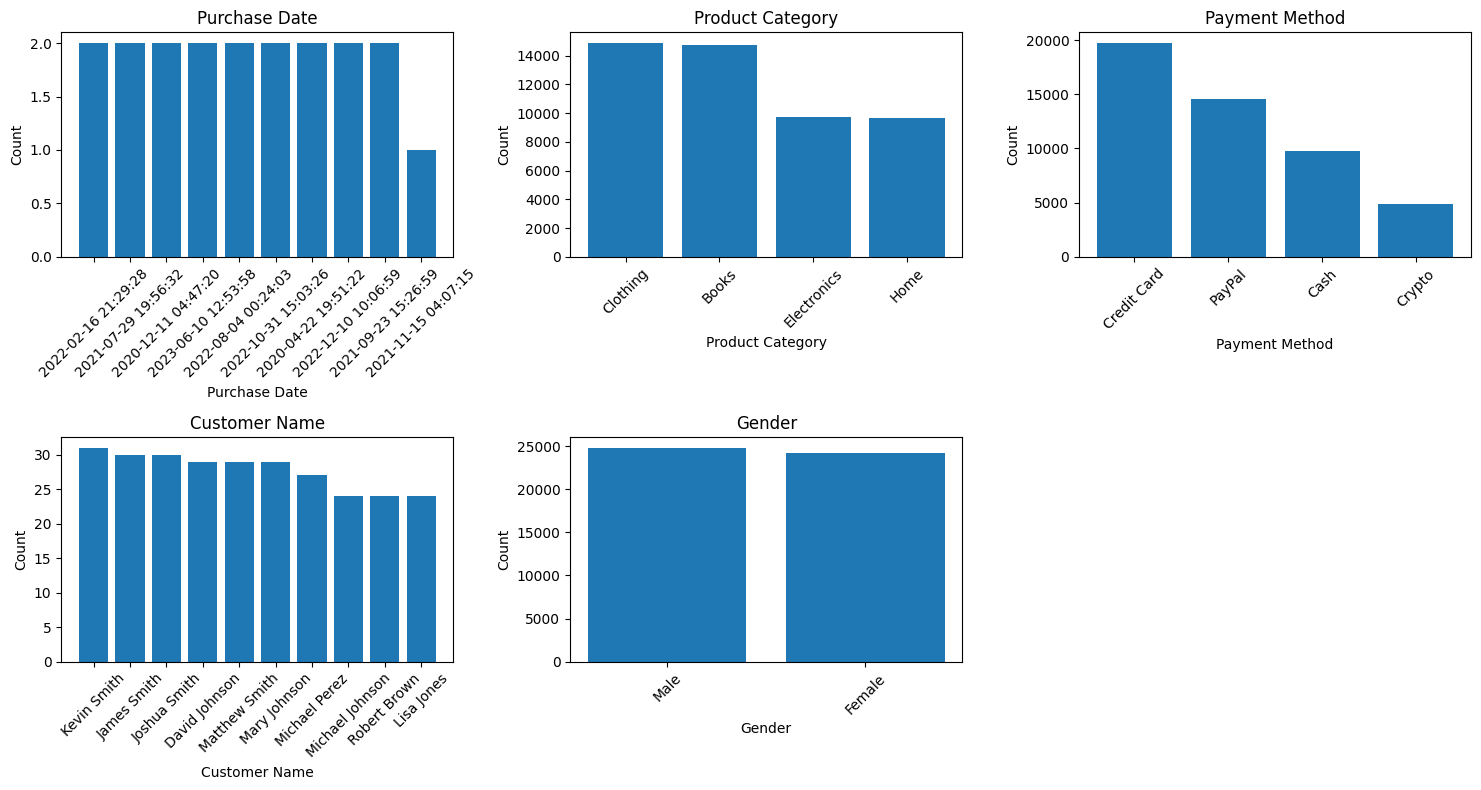

In [14]:
categorical_cols = df.select_dtypes(include='object').columns

n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    # Count categories
    counts = df[col].value_counts().head(10)

    # Plot
    axes[i].bar(counts.index.astype(str), counts.values)

    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

    axes[i].tick_params(axis='x', rotation=45)

# Remove unused axes
for i in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

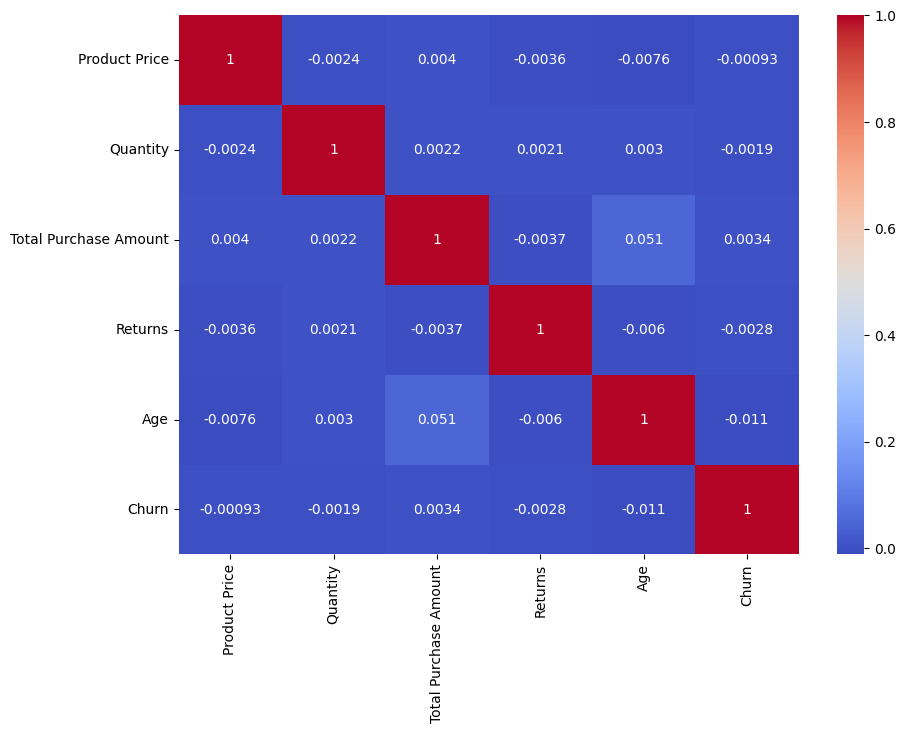

In [15]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [16]:
df['Churn'].value_counts()


,count
Churn,
0.0,39143
1.0,9818


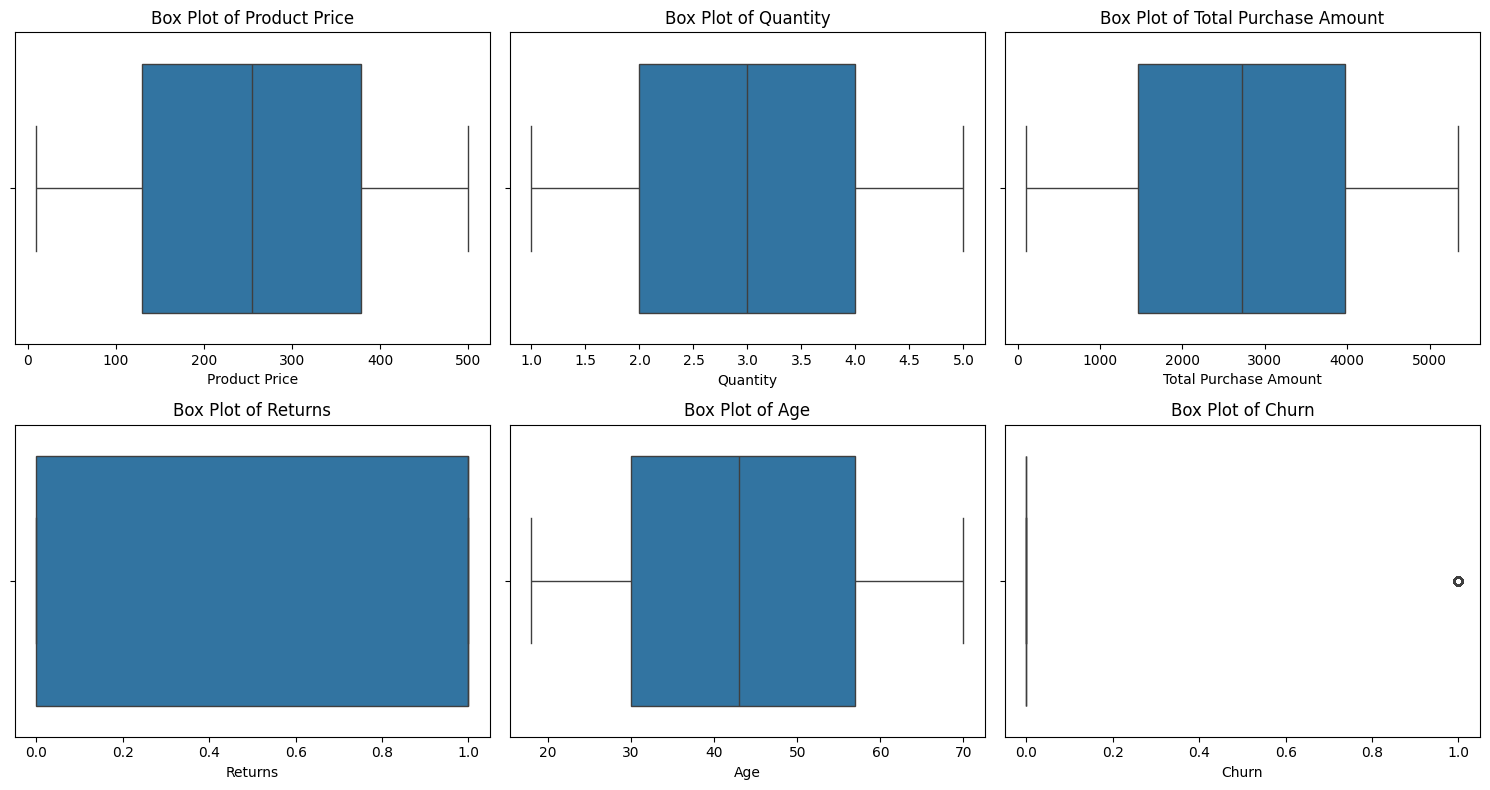

In [17]:
numeric_cols = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        data=df,
        x=col,
        ax=axes[i]
    )

    axes[i].set_title(f'Box Plot of {col}')

# Remove empty subplots
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [19]:
df.shape

(48962, 11)

In [18]:
df.isnull().sum()

,0
Purchase Date,0
Product Category,1
Product Price,1
Quantity,1
Total Purchase Amount,1
Payment Method,1
Returns,9337
Customer Name,1
Age,1
Gender,1


In [33]:
df['Returns'].value_counts(dropna=False)

,count
Returns,
1.0,19839
0.0,19786
NaN,9337


In [34]:
df['Returns'].isna().sum()

np.int64(9337)

In [35]:
df[df['Returns'].isna()].describe()

,Product Price,Quantity,Total Purchase Amount,Returns,Age,Churn
count,9336.000000,9336.000000,9336.000000,0.0,9336.000000,9336.000000
mean,255.774100,2.989182,2724.756855,NaN,43.691088,0.204156
std,141.839134,1.406005,1450.697834,NaN,15.496127,0.403105
min,10.000000,1.000000,114.000000,NaN,18.000000,0.000000
25%,131.000000,2.000000,1450.000000,NaN,30.000000,0.000000
50%,258.500000,3.000000,2725.000000,NaN,43.000000,0.000000
75%,378.000000,4.000000,3996.250000,NaN,57.000000,0.000000
max,500.000000,5.000000,5350.000000,NaN,70.000000,1.000000


In [36]:
df[df['Returns'].isna()][
    ['Product Price', 'Quantity', 'Total Purchase Amount', 'Age']
].describe()

,Product Price,Quantity,Total Purchase Amount,Age
count,9336.000000,9336.000000,9336.000000,9336.000000
mean,255.774100,2.989182,2724.756855,43.691088
std,141.839134,1.406005,1450.697834,15.496127
min,10.000000,1.000000,114.000000,18.000000
25%,131.000000,2.000000,1450.000000,30.000000
50%,258.500000,3.000000,2725.000000,43.000000
75%,378.000000,4.000000,3996.250000,57.000000
max,500.000000,5.000000,5350.000000,70.000000


In [30]:
X = df.drop(['Churn','Returns'],axis = 1)
y = df['Churn']

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

features = [
    'Product Price',
    'Quantity',
    'Total Purchase Amount',
    'Age'
]

X = df[features]

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_scaled = preprocessor.fit_transform(X)

In [39]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K={k} | Silhouette Score={score:.4f}")

K=2 | Silhouette Score=0.1846
K=3 | Silhouette Score=0.1744
K=4 | Silhouette Score=0.1886
K=5 | Silhouette Score=0.1940
K=6 | Silhouette Score=0.1935
K=7 | Silhouette Score=0.2096
K=8 | Silhouette Score=0.2265
K=9 | Silhouette Score=0.2170
K=10 | Silhouette Score=0.2156


In [41]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,6016
1,6239
2,6100
3,6102
4,6124
5,6202
6,6116
7,6063


In [42]:
cluster_profile = df.groupby('Cluster').agg(
    Customers=('Cluster', 'size'),
    Churn_Rate=('Churn', 'mean'),
    Avg_Age=('Age', 'mean'),
    Avg_Product_Price=('Product Price', 'mean'),
    Avg_Quantity=('Quantity', 'mean'),
    Avg_Total_Purchase=('Total Purchase Amount', 'mean')
)

cluster_profile

,Customers,Churn_Rate,Avg_Age,Avg_Product_Price,Avg_Quantity,Avg_Total_Purchase
Cluster,,,,,,
0,6016,0.202460,55.880153,140.865858,4.127660,1679.527261
1,6239,0.200994,31.443340,357.591922,4.072928,1486.965700
2,6100,0.198361,56.492459,148.501803,1.931803,3939.153770
3,6102,0.200787,31.863137,140.955089,4.101787,3768.665792
4,6124,0.200849,32.098465,141.668844,1.827727,1592.184193
5,6202,0.200903,55.010964,373.310867,4.108836,3886.414382
6,6116,0.203891,31.675605,364.113800,1.886691,3810.557063
7,6063,0.195943,55.059706,362.222497,1.884711,1592.605641


In [40]:
final_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(
        n_clusters=8,
        random_state=42,
        n_init=10
    ))
])

df['Cluster'] = final_pipeline.fit_predict(X)